In [ ]:
%reset -f -s
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
from bspline_model import *




# Your current specific workout: 3 reps of (3m low, 1m high) + 2m cooldown
standard_3x4 = WorkoutConfig(phases=[
    WorkoutPhase(f"R1", 180, 'low'), WorkoutPhase(f"S1", 60, 'high'),
    WorkoutPhase(f"R2", 180, 'low'), WorkoutPhase(f"S2", 60, 'high'),
    WorkoutPhase(f"R3", 180, 'low'), WorkoutPhase(f"S3", 60, 'high'),
    WorkoutPhase("Cd", 120, 'cooldown')
], name="standard_3x4")

xtrainer_4x4 = WorkoutConfig(phases=[
    WorkoutPhase(f"R1", 180, 'low'), WorkoutPhase(f"S1", 180, 'high'),
    WorkoutPhase(f"R2", 180, 'low'), WorkoutPhase(f"S2", 180, 'high'),
    WorkoutPhase(f"R3", 180, 'low'), WorkoutPhase(f"S3", 180, 'high'),
    WorkoutPhase(f"R3", 180, 'low'), WorkoutPhase(f"S3", 180, 'high'),
    WorkoutPhase("Cd", 120, 'cooldown')
], name="xtrainer_4x4")


workout_df = pd.DataFrame([
    ('polar_data/oo_dd_2025-12-24_18-32-17.CSV', standard_3x4.name, 130, 0),
    ('polar_data/oo_dd_2025-12-30_11-32-46.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-02_17-45-25.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-05_16-54-37.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-07_17-13-36.CSV', standard_3x4.name, 240, 0), 
    ('polar_data/oo_dd_2026-01-15_16-59-15.CSV', xtrainer_4x4.name, 0, 0)
    ],
    columns=["file_path", "workout_config", "n_drop", "kernel_size"]).assign(
        session_name=lambda x: [Path(p).stem[6:16] for p in x.file_path],
        cache_path=lambda x: [str(Path(p).with_suffix(".nc")) for p in x.file_path]
    )

wc = standard_3x4
sessions = []
for session_row in list(workout_df.loc[lambda x: x.workout_config == wc.name].itertuples(index=False)):
    session_df = pd.read_csv(session_row.file_path, skiprows=2).iloc[session_row.n_drop:, 1:3].assign(
        time_sec=lambda x: pd.to_timedelta(x.Time).dt.total_seconds() - session_row.n_drop
    )
    sessions.append(
        TreadmillAnalytic(session_df.time_sec.values, session_df['HR (bpm)'].values, session_row.session_name, 3, wc, True, Path(session_row.cache_path))
    )
report = TreadmillReport(wc, sessions, False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


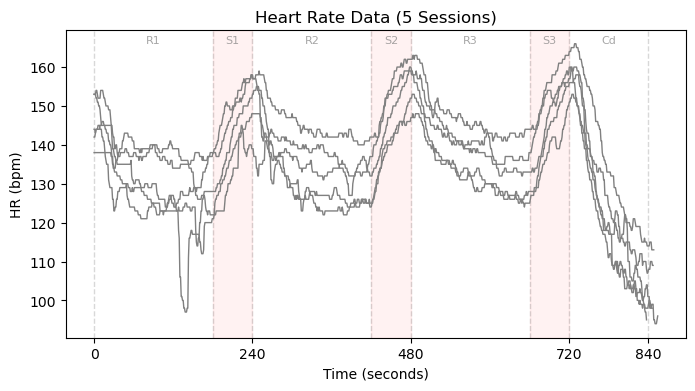

In [63]:
report.plot_raw_data()

# B-Splines

/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  
/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  
/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  
/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  
/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:82: FutureWarni

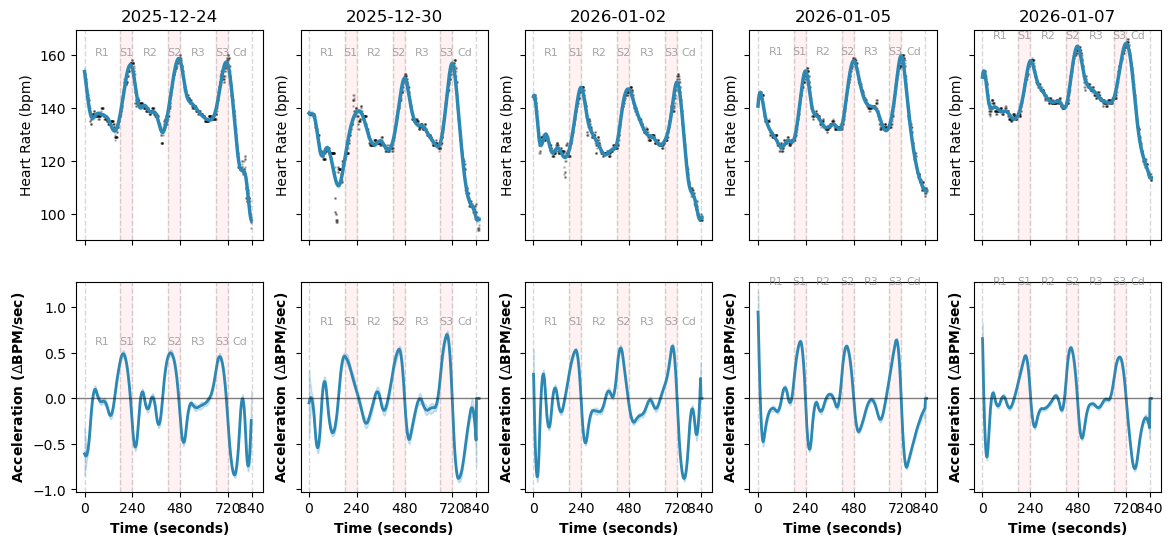

In [ ]:
fig, axes = plt.subplots(ncols=min(len(sessions), 3), nrows=2, figsize=(14, 6), sharex=True, sharey='row')
report.plot_fit_accel(fig, axes)

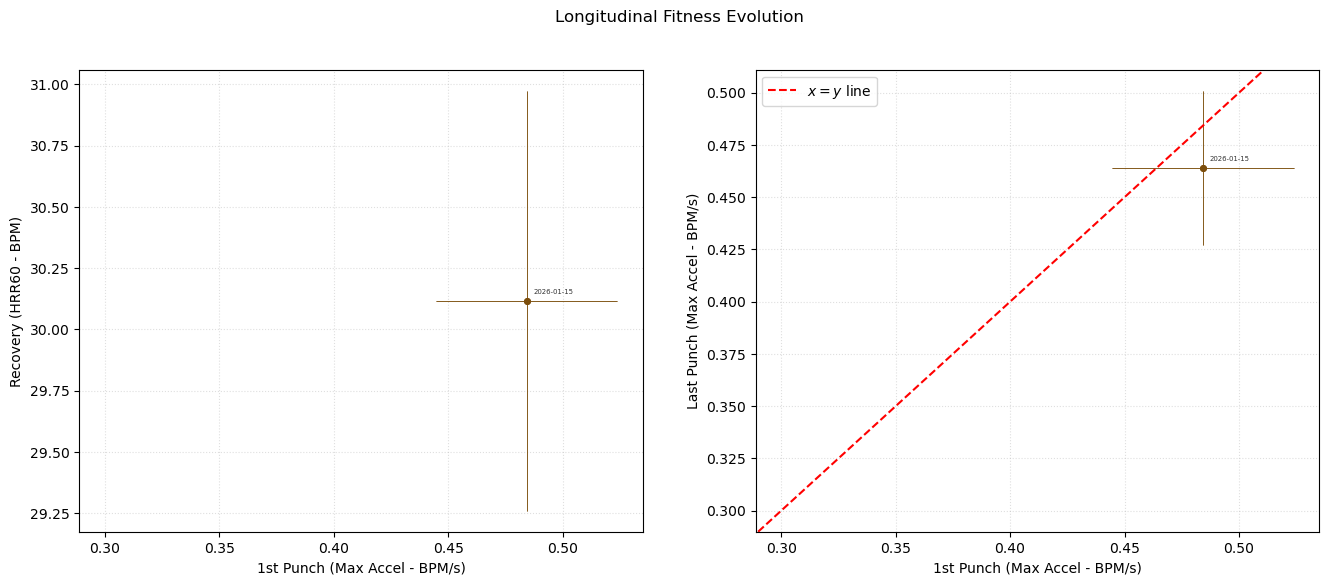

In [57]:
# report = TreadmillReport(standard_3x4, file_paths, False)
fig, ax_quad = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=False)
report.plot_trend_vector(fig, ax_quad[0], 'ph')
report.plot_trend_vector(fig, ax_quad[1], 'pp')
ax_quad[1].axline((0.3, 0.3), slope=1, color='r', linestyle='--', label='$x=y$ line'); ax_quad[1].legend()


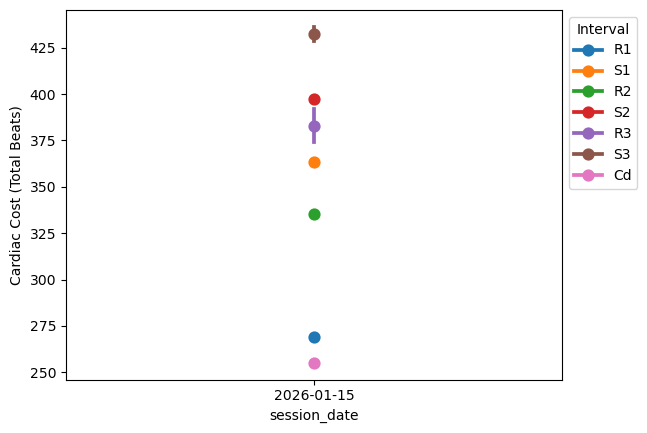

In [58]:
report.plot_cardiac_cost()